# Lab 12: ORB (Oriented FAST and Rotated BRIEF) in OpenCV
This lab introduces the ORB (Oriented FAST and Rotated BRIEF) algorithm, which combines FAST keypoint detection with BRIEF descriptors, enhanced for orientation invariance. The exercises cover detecting and visualizing ORB keypoints, computing descriptors, and matching keypoints between images. Code is designed for a Jupyter Notebook, with images displayed inline using matplotlib.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Exercise 1: ORB Keypoint Detection and Visualization
Task: Detect and visualize ORB keypoints on an image.

(-0.5, 799.5, 449.5, -0.5)

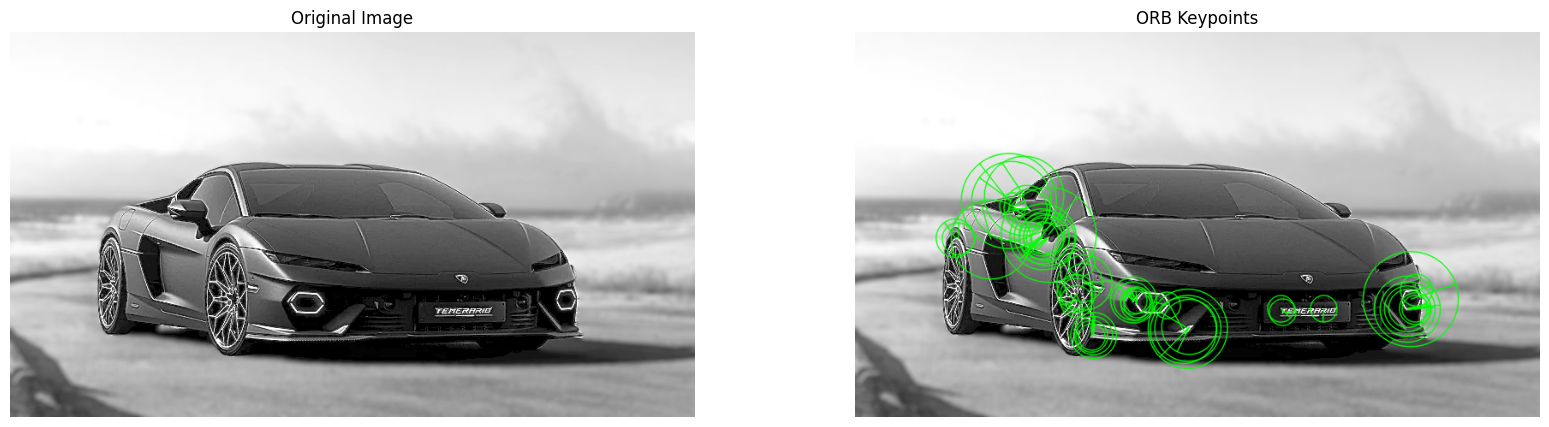

In [2]:
# Load image in grayscale
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found.")
    exit()

# Initialize ORB
orb = cv2.ORB_create(nfeatures=50)

# Detect keypoints and compute descriptors
keypoints, descriptors = orb.detectAndCompute(img, None)

# Draw keypoints
img_orb = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display results
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('ORB Keypoints')
plt.imshow(img_orb, cmap='gray')
plt.axis('off')

## Exercise 2: ORB Keypoint Matching
Task: Match ORB keypoints between two images (e.g., car and a rotated version) using a Hamming distance matcher.

(-0.5, 1249.5, 799.5, -0.5)

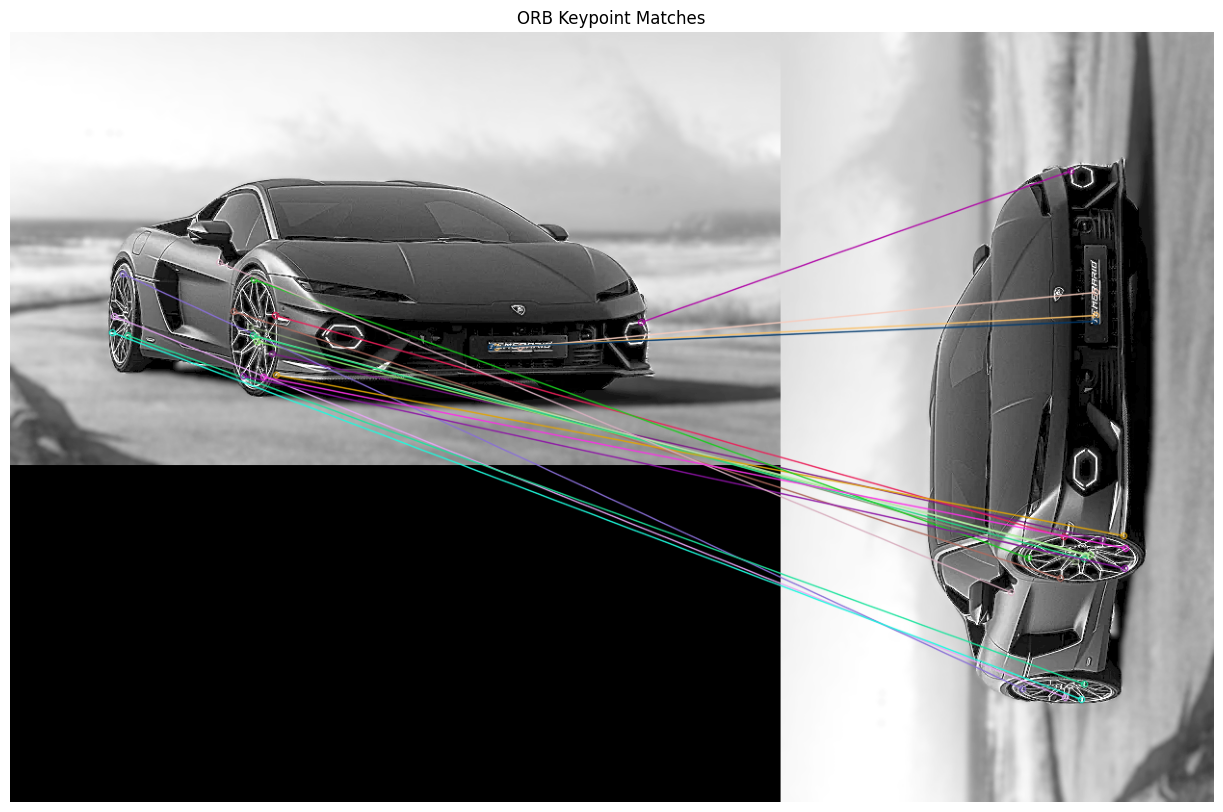

In [3]:
# Load images
img1 = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car_rotated.png', cv2.IMREAD_GRAYSCALE)
if img1 is None or img2 is None:
    print("Error: Image not found.")
    exit()

# Initialize ORB
orb = cv2.ORB_create(nfeatures=500)

# Detect keypoints and compute descriptors
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

# Match descriptors using Hamming distance
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# Sort matches by distance
matches = sorted(matches, key=lambda x: x.distance)

# Draw top 20 matches
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display result
plt.figure(figsize=(20, 10))
plt.title('ORB Keypoint Matches')
plt.imshow(img_matches, cmap='gray')
plt.axis('off')

## Exercise 3: ORB with Varying Keypoint Limits
Task: Detect ORB keypoints with different maximum keypoint limits and visualize matches.

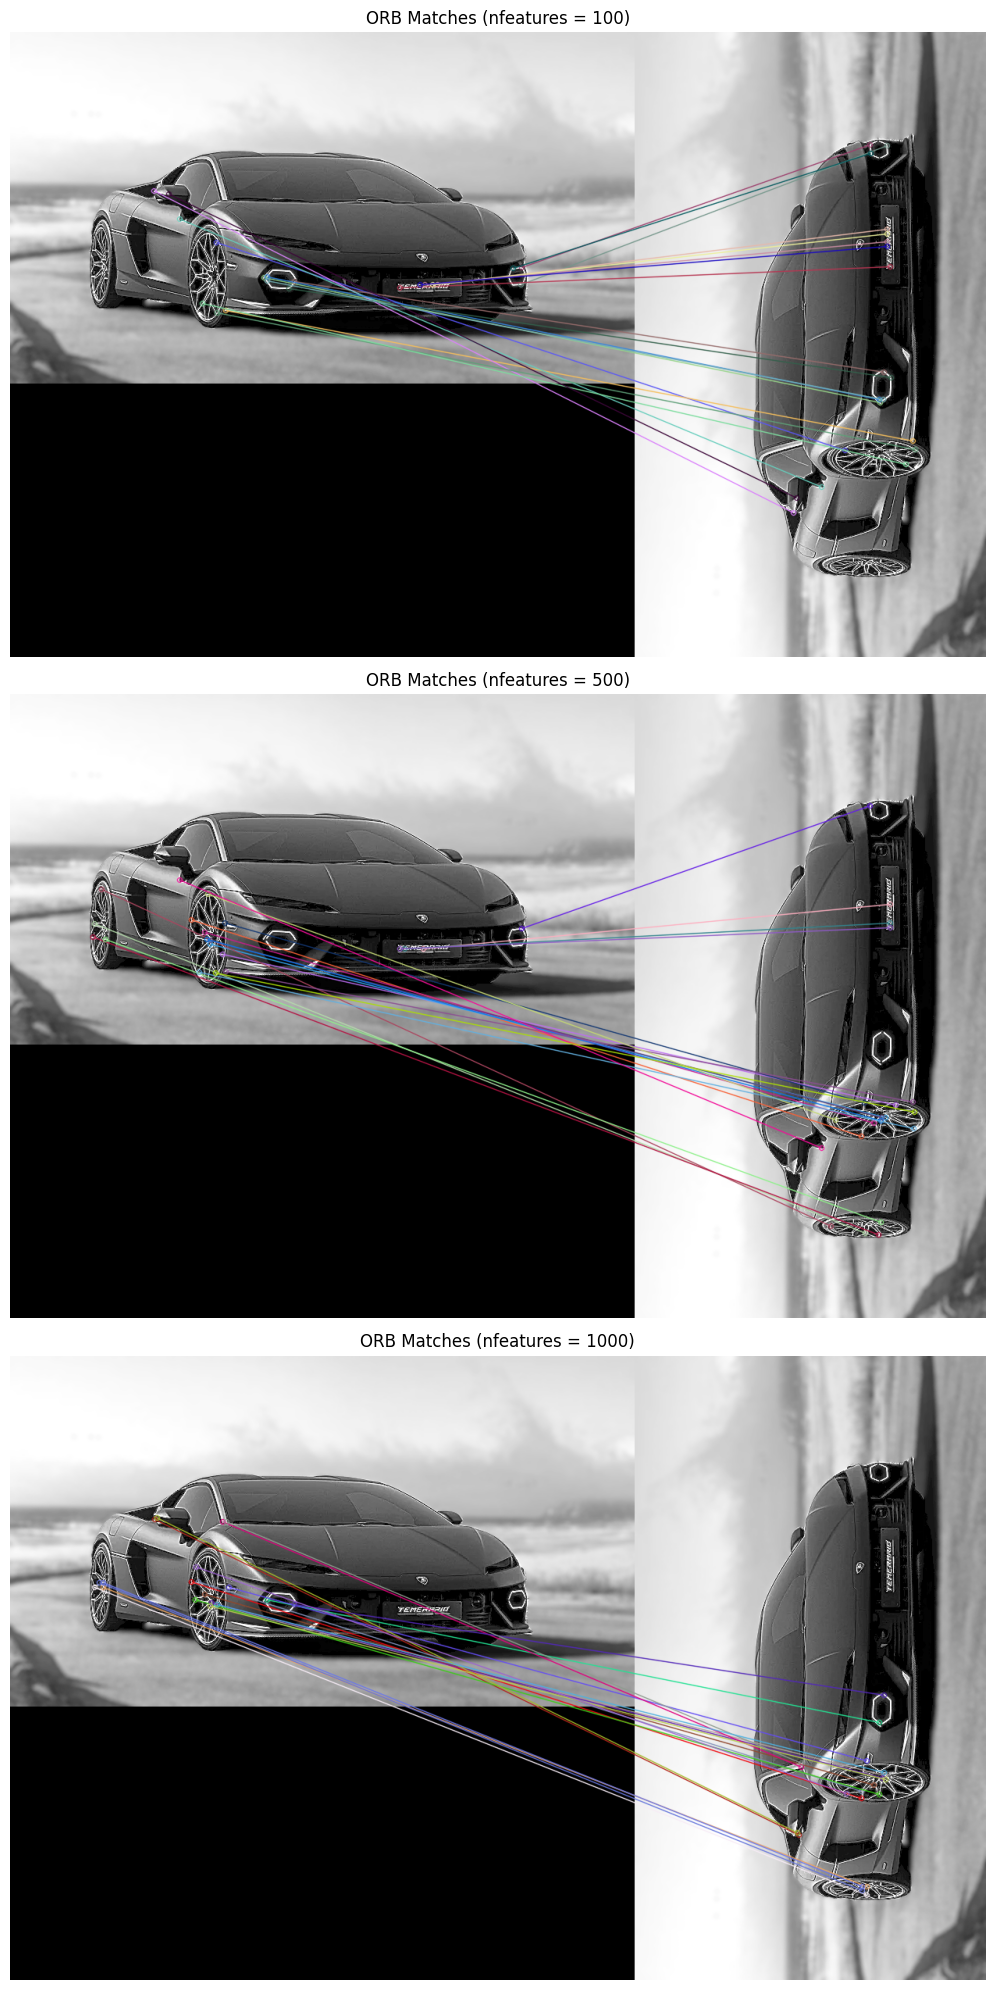

In [4]:
# Load images
img1 = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car_rotated.png', cv2.IMREAD_GRAYSCALE)
if img1 is None or img2 is None:
    print("Error: Image not found.")
    exit()

# Keypoint limits
nfeatures_list = [100, 500, 1000]
img_matches_list = []

for nfeatures in nfeatures_list:
    # Initialize ORB
    orb = cv2.ORB_create(nfeatures=nfeatures)
    
    # Detect keypoints and compute descriptors
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)
    
    # Match descriptors
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    
    # Draw matches
    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None,
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    img_matches_list.append(img_matches)

# Display results
plt.figure(figsize=(20, 20))
for i, nfeatures in enumerate(nfeatures_list):
    plt.subplot(3, 1, i + 1)
    plt.title(f'ORB Matches (nfeatures = {nfeatures})')
    plt.imshow(img_matches_list[i], cmap='gray')
    plt.axis('off')
    
plt.tight_layout()


# By **Saddam Umer**

BS AI, SMIU